In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import math
import random
import matplotlib.pyplot as plt

In [2]:
class Value:

    def __init__(self, data, children = (), op = '', label = ''):
        self.data = data
        self.prev = set(children)
        self.op = op
        self.label = label
        self.grad = 0
        self._backward = lambda:None

    def __repr__(self):
        return f'Value(data={self.data})'

    def __neg__(self):
        return Value(-self.data)

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad += out.grad * 1
            other.grad += out.grad * 1
        out._backward = _backward
        return out
        
    def __radd__(self,other):
        return self + other

    def __sub__(self,other):
        return self + (-other)

    def __rsub__(self,other):
        return self + (-other)

    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data*other.data, (self,other),'*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad* self.data
        out._backward = _backward
        return out

    def __rmul__(self,other):
        return self*other

    def __pow__(self,other):
        assert isinstance(other,(int,float)), 'only supports int/float cuz im an idiot shut up'
        out = Value(self.data**other,(self,),'**')
        def _backward():
            self.grad += out.grad*(other*(self.data**(other-1)))
        out._backward = _backward
        return out 

    def __truediv__(self,other):
        return self * other**-1

    def tanh(self):
        a = math.tanh(self.data)
        out = Value(a,(self,),'tanh')

        def _backward():
            self.grad += out.grad * (1-a**2)
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1
        for node in reversed(topo):
            node._backward()
        
    

In [3]:
a = Value(1) ; a.label = 'a'
b = Value(1) ; b.label = 'b'
c = Value(2) ; c.label = 'c'
q = a+b; q.label = 'q'
r = a*c; r.label = 'r'
p = q*r; p.label = 'p'
L = p.tanh();L.label = 'L'

L.backward()

In [4]:
class Neuron:
    def __init__(self,n_in):
        self.weight = [Value(random.uniform(-1,1)) for _ in range(n_in)]
        self.bias = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((weight*x for weight,x in zip(self.weight,x)),self.bias)
        out = act.tanh()
        return out

    def parameters(self):
        return self.weight + [self.bias]

class Layer:
    def __init__(self,n_in,n_out):
        self.neurons = [Neuron(n_in) for _ in range(n_out)]

    def __call__(self,x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params

class MLP:
    def __init__(self,n_in,n_outs):
        size = [n_in] + n_outs
        self.layers = [Layer(size[i],size[i+1]) for i in range(len(size)-1)]

    def __call__(self,x):
        for l in self.layers:
            x = l(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        



In [5]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
L = n(x)



In [6]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [7]:
def magic(nloops):
    for _ in range(nloops):
        y_pred = [n(x) for x in xs]
        
        for p in n.parameters():
            p.grad = 0
        
        loss = sum((y_gt - y_pred)**2 for y_gt,y_pred in zip(ys,y_pred))
        loss.backward()
        
        for p in n.parameters():
            p.data += -0.1 * p.grad
        print(f'loss = {loss}')

    return y_pred, loss
        

In [8]:
y_pred, loss = magic(20)

y_pred

loss = Value(data=3.4246801127749604)
loss = Value(data=4.199223017084154)
loss = Value(data=2.9684312259365493)
loss = Value(data=0.6489755216280648)
loss = Value(data=0.014727879530893728)
loss = Value(data=0.013973880872932458)
loss = Value(data=0.013294474062278717)
loss = Value(data=0.012678518092058796)
loss = Value(data=0.012117100831113534)
loss = Value(data=0.011602986910249996)
loss = Value(data=0.011130225919495204)
loss = Value(data=0.010693868377826137)
loss = Value(data=0.010289755874297294)
loss = Value(data=0.009914363343204804)
loss = Value(data=0.00956467868796428)
loss = Value(data=0.009238109627412788)
loss = Value(data=0.008932410697752849)
loss = Value(data=0.008645625393115572)
loss = Value(data=0.008376039826431956)
loss = Value(data=0.008122145263020101)


[Value(data=0.9512803295151492),
 Value(data=-0.9702969087027136),
 Value(data=-0.9471342399265572),
 Value(data=0.9544865212260158)]

In [9]:
n.parameters()

[Value(data=-0.6249286002591443),
 Value(data=-0.5596493171056922),
 Value(data=-0.29454034811871765),
 Value(data=0.2653349866852014),
 Value(data=-0.8071050987125697),
 Value(data=-0.7739932107562439),
 Value(data=-0.8769018571019522),
 Value(data=0.3678360016314284),
 Value(data=-0.37187799521646436),
 Value(data=-0.9020277811654509),
 Value(data=0.9084388867440751),
 Value(data=0.8547267698625063),
 Value(data=0.22476775735455182),
 Value(data=0.7568616357713148),
 Value(data=-1.1912807330094537),
 Value(data=-0.5936764876775656),
 Value(data=-0.051118399167278526),
 Value(data=0.11454327759541066),
 Value(data=-1.1974245674779496),
 Value(data=1.1621135915908463),
 Value(data=-0.1936053305525818),
 Value(data=-0.43192205225368374),
 Value(data=0.46136929052115433),
 Value(data=0.6236121714205464),
 Value(data=-0.15538262537742437),
 Value(data=-0.8741355549086598),
 Value(data=0.915794288848682),
 Value(data=-0.21858232434631386),
 Value(data=-0.2848651136415593),
 Value(data=0.93

In [10]:
from graphviz import Digraph

def trace(root): #construct all the nodes and edges in the network
    nodes, edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir':'LR'})

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad), shape='record')
        if n.op:
            dot.node(name = uid + n.op, label = n.op)
            dot.edge(uid+n.op, uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot

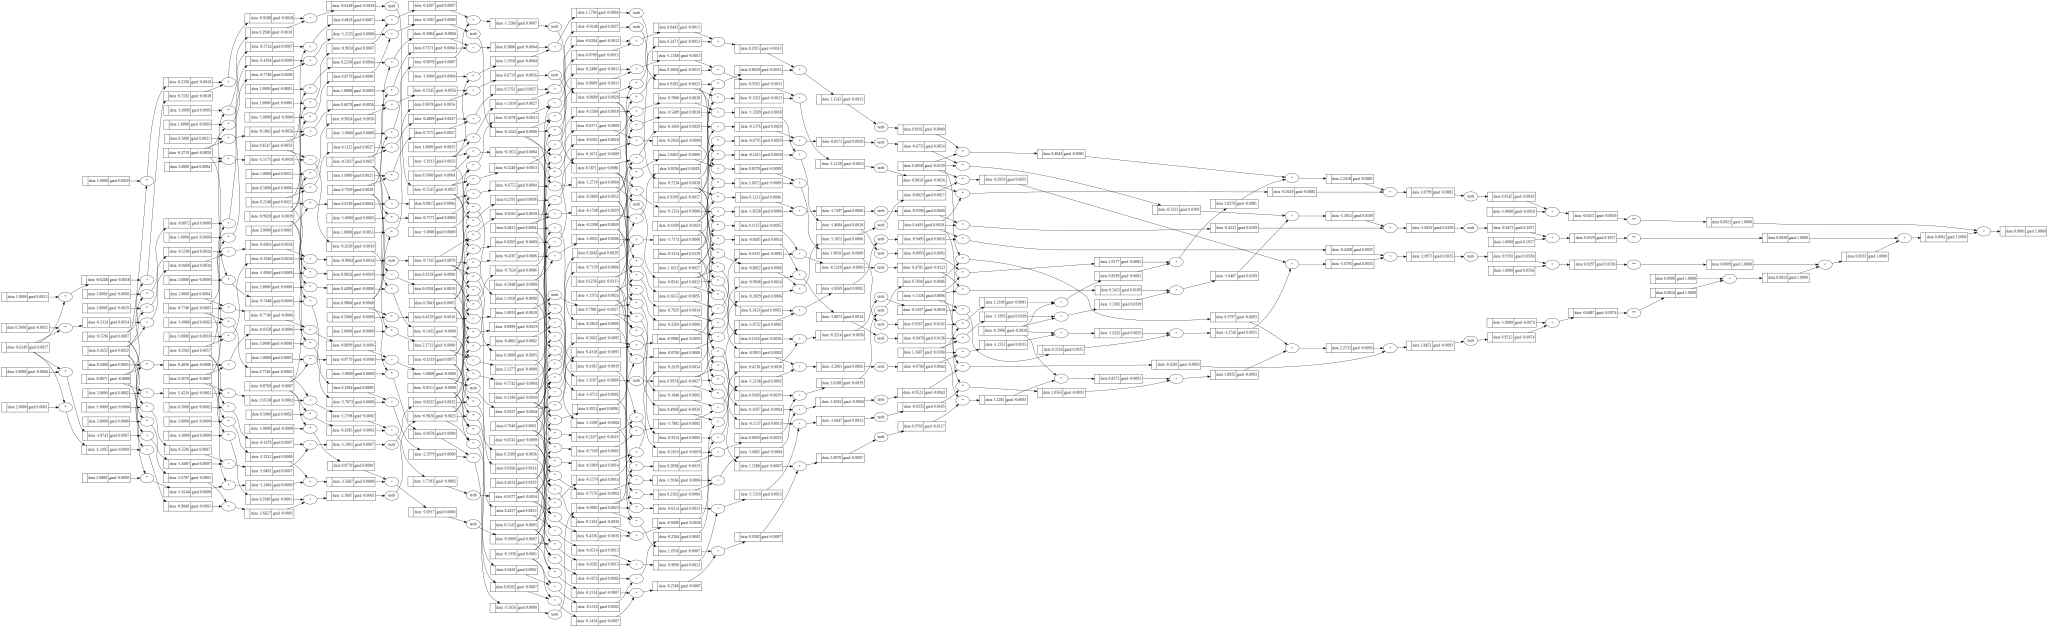

In [11]:
draw_dot(loss)